# 🐟 Red Sea Fish Production: A Complete Data Science Project

## Simple Explanation for Everyone

**What is this project about?**
"We are analyzing FAO datasets to understand the sustainability of aquatic food systems in the Red Sea region."
**How it works (Simple Analogy):**
- Imagine you observe a child's height every year: Age 5→110cm, Age 6→120cm, Age 7→130cm...
- You notice the pattern: Height increases by ~10cm per year
- So you can predict: Age 8→140cm, Age 9→150cm (by following the pattern)
- **Our project does the same thing** but for fish production!
- **Note**: Just like a child's growth eventually slows down, real-world fish production is limited by environmental factors. Our model provides a baseline trend."
**The Steps We Follow:**
1.  **Data Cleaning** - Clean and prepare the raw data
2.  **EDA (Exploratory Data Analysis)** - Understand the data
3.  **Data Visualization** - Draw graphs and charts
4.  **Model Building** - Create a machine to make predictions
5.  **Evaluation** - "Evaluation: Measuring the reliability of our model using R-squared and Error metrics."


---
##  STEP 0: SETUP
**What are we doing?** We're importing tools (libraries) that we need to work with data.

**Real-world example:** Like opening your toolbox before fixing a car. We need hammers, wrenches, etc.


In [151]:
# Import Libraries (Load our tools)
import numpy as np         # Tool for mathematical calculations
import pandas as pd        # For data manipulation and building the master dataset.
import matplotlib.pyplot as plt  # matplotlib/seaborn: For exploratory data analysis (EDA) and research visualizations.
import seaborn as sns      # Tool for making beautiful graphs
import os                  # Tool for working with files

# Check where we are on the computer
print(os.getcwd())
print(' All tools loaded successfully!')

D:\JupyterWork\FOA Analysis\notebook
 All tools loaded successfully!


**📊 Output Explanation:** This shows the folder where our notebook is located.
It's like confirming we're in the right location before starting work.

In [153]:
# Configure pandas to show all columns (not hide them)
pd.set_option('display.max_columns', None)

**Why?** When we look at data with many columns, pandas normally hides some. This setting tells pandas to show everything.

---
## STEP 1: DATA LOADING
**What are we doing?** Loading data from CSV files into our notebook.

**Real-world example:** Like opening 5 different folders with different information:
- Folder 1: Fish catch amounts (how much fish was caught)
- Folder 2: Country information (which countries, their location, wealth level)
- Folder 3: Fish species information (names and types of fish)
- Folder 4: Water area information (which ocean/sea areas)
- Folder 5: Unit information (how we measure things - tonnes, kg, etc.)


In [156]:
# Load the datasets (Open all our data folders)
capture_df = pd.read_csv(r'D:\JupyterWork\FOA Analysis\notebook\data\Capture_Quantity.csv')
country_df = pd.read_csv(r'D:\JupyterWork\FOA Analysis\notebook/data/CL_FI_COUNTRY_GROUPS.csv')
species_df = pd.read_csv(r'D:\JupyterWork\FOA Analysis\notebook/data/CL_FI_SPECIES_GROUPS.csv')
water_area_df = pd.read_csv(r'D:\JupyterWork\FOA Analysis\notebook/data/CL_FI_WATERAREA_GROUPS.csv')
unit_df = pd.read_csv('FSJ_UNIT.csv')
print(' All data loaded! Now let\'s explore it...')

 All data loaded! Now let's explore it...


**Output:** A confirmation message showing all files were loaded successfully.

---
##  STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
**What are we doing?** Looking at the basic information about our data.

**Real-world example:** When you get a new car, you check:
- How many doors does it have?
- How many seats?
- What's the engine size?
- Are there any missing parts?

**We do the same with data!**

In [159]:
# We are examining the metadata and dimensions (shapes) of our datasets to understand their scale before merging."
print('═' * 60)
print('FISH CATCH DATA')
print('═' * 60)
print(capture_df.columns)
print('Shape (Rows, Columns):', capture_df.shape)
print("\n" , "=" * 60)   

print('COUNTRY DATA')
print('═' * 60)
print(country_df.columns)
print('Shape (Rows, Columns):', country_df.shape)

════════════════════════════════════════════════════════════
FISH CATCH DATA
════════════════════════════════════════════════════════════
Index(['COUNTRY.UN_CODE', 'SPECIES.ALPHA_3_CODE', 'AREA.CODE', 'MEASURE',
       'PERIOD', 'VALUE', 'STATUS'],
      dtype='object')
Shape (Rows, Columns): (1030435, 7)

COUNTRY DATA
════════════════════════════════════════════════════════════
Index(['UN_Code', 'Identifier', 'ISO2_Code', 'ISO3_Code', 'Name_En', 'Name_Fr',
       'Name_Es', 'Name_Ar', 'Name_Cn', 'Name_Ru', 'Official_Name_En',
       'Official_Name_Fr', 'Official_Name_Es', 'Official_Name_Ar',
       'Official_Name_Cn', 'Official_Name_Ru', 'Continent_Group_En',
       'Continent_Group_Fr', 'Continent_Group_Es', 'Continent_Group_Ar',
       'Continent_Group_Cn', 'Continent_Group_Ru', 'EcoClass_Group_En',
       'EcoClass_Group_Fr', 'EcoClass_Group_Es', 'EcoClass_Group_Ar',
       'EcoClass_Group_Cn', 'EcoClass_Group_Ru', 'GeoRegion_Group_En',
       'GeoRegion_Group_Fr', 'GeoRegion_Group

**Output Explanation:**
- **Fish Catch Data (1,030,435 rows × 7 columns):**
  - COUNTRY.UN_CODE: Which country
  - SPECIES.ALPHA_3_CODE: Type of fish
  - AREA.CODE: Which water area
  - VALUE: How much was caught (in tonnes)
  - PERIOD: Which year

- **Country Data (275 rows × 34 columns):**
  - Information about each country (name, continent, economic level, etc.)

**Think of it like:** Fish catch data is like 1 million receipts from a fishery. Country data is like a customer database.

---
##  STEP 3: DATA CLEANING
**What are we doing?** Organizing and fixing our data to remove unnecessary parts.

**Real-world example:** When you buy groceries, you:
- Remove damaged items
- Sort fruits from vegetables
- Label everything clearly

**We do the same with data - we keep only what we need!**

In [162]:
# "Dimensionality Reduction: 
# Filtering out multi-language duplicates to keep only essential descriptive columns for geospatial and socioeconomic analysis."
country_clean = country_df[[
    'UN_Code', 'ISO3_Code', 'Name_En', 
    'Continent_Group_En', 'EcoClass_Group_En', 'GeoRegion_Group_En'
]].copy()

print('=' * 40)
print('Country Data Sample:')
print('=' * 40)
print(country_clean.head(3))


Country Data Sample:
   UN_Code ISO3_Code      Name_En Continent_Group_En  \
0       51       ARM      Armenia               Asia   
1        4       AFG  Afghanistan               Asia   
2        8       ALB      Albania             Europe   

               EcoClass_Group_En GeoRegion_Group_En  
0  Upper-middle income countries       Western Asia  
1           Low-income countries      Southern Asia  
2  Upper-middle income countries    Southern Europe  


**Why we do this:** The country file had 34 columns, but we only need 6. Keeping only what we need makes our work faster and cleaner.

In [164]:
# Combine (merge) fish catch data with country information
# This is like connecting two puzzle pieces:
# - Puzzle 1: Fish catch data with country codes
# - Puzzle 2: Country information with country codes
# They fit together using the country code!

master_df = pd.merge(
    capture_df, 
    country_clean,
    left_on='COUNTRY.UN_CODE',
    right_on='UN_Code',
    how='inner'
)
print(' Merged successfully!')
print(f'New data shape: {master_df.shape}')

 Merged successfully!
New data shape: (1030435, 13)


**Why we do this:** Now we have one big table with:
- Fish catch numbers
- Country names
- Continent information
- Socioeconomic status (Income level)

All in ONE place, which makes analysis easier!

In [166]:
#  Filter for Red Sea countries only
# (These are the countries that fish in the Red Sea)

red_sea_countries = [
    'Saudi Arabia', 'Egypt', 'Sudan', 'Yemen', 
    'Eritrea', 'Djibouti', 'Israel','Jordan'
]

red_sea_df = master_df[master_df['Name_En'].isin(red_sea_countries)].copy()
print(f' Filtered to Red Sea countries')
print(f'Red Sea data shape: {red_sea_df.shape}')
print(f'\nRed Sea countries in data:')
print(red_sea_df['Name_En'].unique())

 Filtered to Red Sea countries
Red Sea data shape: (21138, 13)

Red Sea countries in data:
['Djibouti' 'Egypt' 'Eritrea' 'Israel' 'Jordan' 'Saudi Arabia' 'Sudan'
 'Yemen']


**Why filter?** The world data is too big and has too many countries. We want to focus on just the Red Sea region to find patterns specific to that area.

**Real-world example:** If you want to study city traffic, you study ONE city, not the whole world!

In [168]:
# Add species (fish type) information

# First, clean species data
species_clean = species_df[['3A_Code', 'Scientific_Name', 'Major_Group', 'ISSCAAP_Group_En', 'CPC_Group_En'
]].copy()

# Merge with our Red Sea data
red_sea_final = pd.merge(
    red_sea_df, 
    species_clean,
    left_on='SPECIES.ALPHA_3_CODE',
    right_on='3A_Code',
    how='inner'
)

print(' Species information added!')
print(f'Final data shape: {red_sea_final.shape}')
print(f'\nColumn names:')
print(red_sea_final.columns.tolist())

 Species information added!
Final data shape: (21138, 18)

Column names:
['COUNTRY.UN_CODE', 'SPECIES.ALPHA_3_CODE', 'AREA.CODE', 'MEASURE', 'PERIOD', 'VALUE', 'STATUS', 'UN_Code', 'ISO3_Code', 'Name_En', 'Continent_Group_En', 'EcoClass_Group_En', 'GeoRegion_Group_En', '3A_Code', 'Scientific_Name', 'Major_Group', 'ISSCAAP_Group_En', 'CPC_Group_En']


**What just happened:** We now have a complete dataset with:
- Year (PERIOD)
- Country name
- Fish type/species
- Catch amount (VALUE)
- **Result**: We now have a fully harmonized regional dataset. By merging the spatial metadata with taxonomic classifications, each observation now contains the exact geographic origin, socioeconomic status of the country, and biological groupings of the catch. This is our foundation for the upcoming baseline sustainability analysis."
Everything in one table!

In [170]:
# Check for missing values (holes in our data)

print('Missing values (holes) in our data:')
print(red_sea_final.isnull().sum())
print('\nData info:')
red_sea_final.info()

Missing values (holes) in our data:
COUNTRY.UN_CODE             0
SPECIES.ALPHA_3_CODE        0
AREA.CODE                   0
MEASURE                     0
PERIOD                      0
VALUE                       0
STATUS                  19136
UN_Code                     0
ISO3_Code                   0
Name_En                     0
Continent_Group_En          0
EcoClass_Group_En           0
GeoRegion_Group_En          0
3A_Code                     0
Scientific_Name             0
Major_Group                 0
ISSCAAP_Group_En            0
CPC_Group_En              118
dtype: int64

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21138 entries, 0 to 21137
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   COUNTRY.UN_CODE       21138 non-null  int64  
 1   SPECIES.ALPHA_3_CODE  21138 non-null  object 
 2   AREA.CODE             21138 non-null  int64  
 3   MEASURE               21138 no

**Output Explanation:**
"Research Insight on Knowledge Gaps: The high volume of missing values in the 'STATUS' column (19,136 out of 21,138 rows) indicates that the vast majority of official regional catch records lack statistical flags (e.g., whether the data is estimated or officially reported). This highlights a critical reporting and knowledge gap in Red Sea fisheries management."

---
##  STEP 4: DATA VISUALIZATION
**What are we doing?** Drawing graphs and charts to understand patterns.

**Real-world example:** Numbers are hard to understand:
- "Population increased by 50%" is confusing
- But a graph showing , makes it instantly clear!

**We use graphs to "see" patterns in the data!**

In [173]:
# Total catch per year (yearly trend)
print('Calculating total catch per year...')
yearly_trend = red_sea_final.groupby('PERIOD')['VALUE'].sum()

print(' Yearly data prepared')
print(yearly_trend.head())

Calculating total catch per year...
 Yearly data prepared
PERIOD
1950    73000.0
1951    80300.0
1952    89900.0
1953    87100.0
1954    93200.0
Name: VALUE, dtype: float64


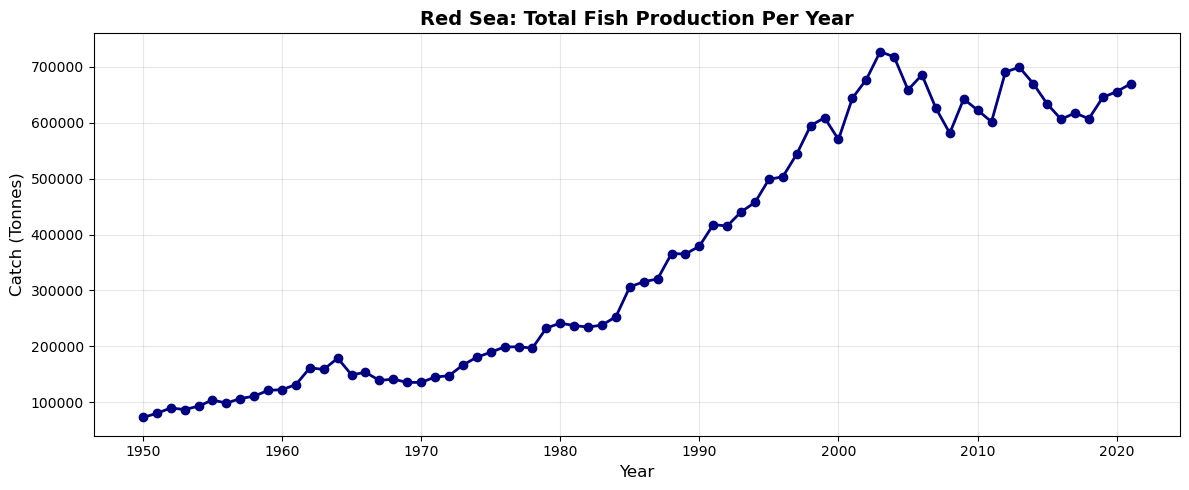

 Graph shows: Fish production is INCREASING over time!


In [174]:
# Draw Graph 1: Yearly Trend
plt.figure(figsize=(12, 5))
yearly_trend.plot(kind='line', marker='o', color='navy', linewidth=2)
plt.title('Red Sea: Total Fish Production Per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Catch (Tonnes)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(' Graph shows: Fish production is INCREASING over time!')

**Graph Explanation:**
- The line goes UP, which means:
  - Phase 1 (1950 - 2000): Continuous and rapid growth in production.
  - Phase 2 (2000 - 2021): Production has hit a ceiling and is stagnating around 600,000 to 700,000 tonnes, indicating the ecological limit of wild-    caught fisheries.

**Why this matters:** Even though there are short-term fluctuations, the overall long-term upward trend allows us to build a predictive model to forecast future capacity."

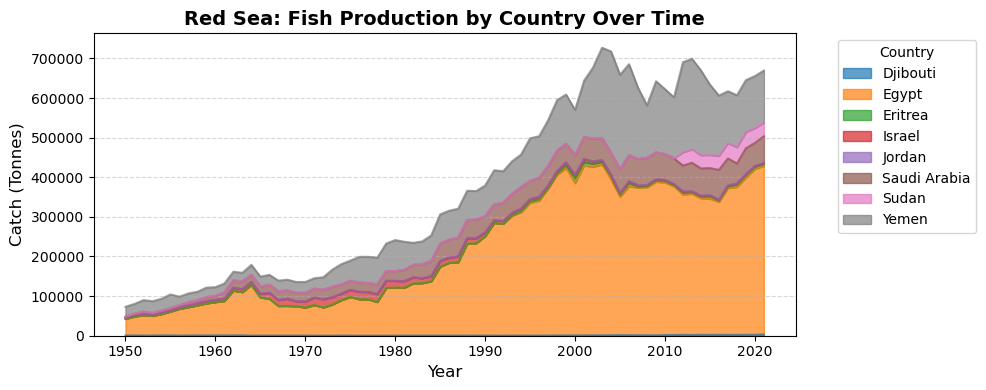

In [176]:
# Catch by Country
country_yearly = red_sea_final.groupby(['PERIOD', 'Name_En'])['VALUE'].sum().unstack(fill_value=0)

#plt.figure(figsize=(10, 4))
country_yearly.plot(kind='area',figsize=(10,4), alpha=0.7)
plt.title('Red Sea: Fish Production by Country Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Catch (Tonnes)', fontsize=12)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


**Graph Explanation:**
This 'stacked area' chart shows:
- Each colored section = one country
- The height of each section = how much that country caught
- Which countries catch the most fish? -> Egypt is the dominant producer, followed by Yemen and Saudi Arabia.
- Is the total increasing or decreasing? -> Total production peaked around 2004 and has since been fluctuating around a flat plateau, showing signs of regional stabilization or ecological limits.

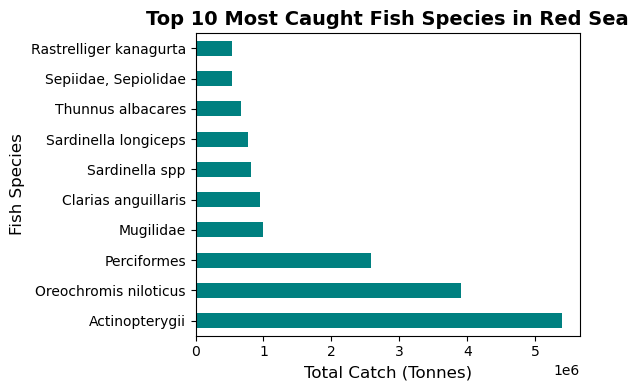

In [178]:
#Top 10 most caught fish species
top_species = red_sea_final.groupby('Scientific_Name')['VALUE'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(6, 4))
top_species.plot(kind='barh', color='teal')
plt.title('Top 10 Most Caught Fish Species in Red Sea', fontsize=14, fontweight='bold')
plt.xlabel('Total Catch (Tonnes)', fontsize=12)
plt.ylabel('Fish Species', fontsize=12)
plt.tight_layout()
plt.show()

**Graph Explanation:**
This bar chart shows:
- Which types of fish are caught the MOST
- **The Longest Bar (Dominant Taxa)**: Represents the most heavily exploited or reported fish group in the region across the historical timeline.
- **Taxonomic Resolution Gap**: If the longest bar belongs to broad categories like Actinopterygii (ray-finned fishes) or Perciformes rather than a specific species, it indicates a significant Knowledge Gap. This proves that a large volume of regional catch data is reported at a very low resolution, masking the true biodiversity and species-level exploitation trends in the Red Sea.

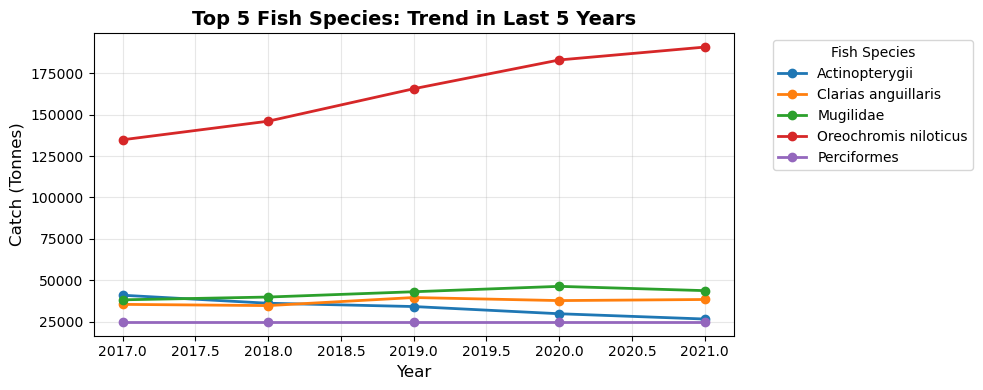

In [180]:
#Trend of top 5 species in recent years
# Look at last 5 years only
recent_5_years = red_sea_final[red_sea_final['PERIOD'] >= red_sea_final['PERIOD'].max() - 4]
top_5_list = top_species.head(5).index.tolist()

recent_trend = recent_5_years[recent_5_years['Scientific_Name'].isin(top_5_list)].groupby(['PERIOD', 'Scientific_Name'])['VALUE'].sum().unstack(fill_value=0)

recent_trend.plot(kind='line', marker='o', linewidth=2,figsize=(10,4))
plt.title('Top 5 Fish Species: Trend in Last 5 Years', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Catch (Tonnes)', fontsize=12)
plt.legend(title='Fish Species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Graph Explanation:**
This line chart shows:
- How each of the top 5 fish species is doing
- Which species are increasing in catch?
- Which species are decreasing?
- Are they stable or changing?

## 🤖 MODEL BUILDING
### What is a Model?
- A machine learning model is a mathematical algorithm that learns from historical patterns to generate predictive insights about the future.
## Real-world application:

* Epidemiologists use historical clinical tests to forecast public health outcomes.
* Agronomists analyze historical meteorological patterns to optimize crop yields.
* Our approach: We utilize long-term historical landing data to predict future fishery exploitation and production capacities.

## Why Linear Regression?
Linear Regression establishes a baseline predictive trajectory by computing the optimal straight line (the line of best fit) through the data points to minimize variance.
## Analytical Analogy:

* If you track human physiological growth across early developmental stages, the trend closely mirrors a continuous upward trajectory.
* By plotting a baseline trend line, you can mathematically project future structural growth targets.
* Our Data: The aggregated regional capture statistics demonstrate a clear, stable long-term baseline trajectory suitable for linear modeling.

## Mathematical Formulation: $y = mx + b$

* $y$ (Dependent Variable): Projected fishery catch volume (Tonnes).
* $x$ (Independent Variable): Temporal vector (Year).
* $m$ (Coefficient/Slope): The annual rate of change in catch volume.
* $b$ (Intercept): The foundational baseline reference point.

## Why choose it?
- Linear Regression serves as the optimal industry-standard baseline model for time-series evaluation. It provides direct interpretability, allowing us to quantify exactly how many tonnes the regional production shifts with each passing year before introducing complex non-linear structures.

In [183]:
# Prepare data for the model
# The model needs data in specific format:
# X = input (years), y = output (fish catch amounts)

X = yearly_trend.index.values.reshape(-1, 1)  # Years (input)
y = yearly_trend.values                        # Fish catch (output)

print('Data prepared for model:')
print(f'X (Years): {X.shape}')
print(f'y (Catch): {y.shape}')

Data prepared for model:
X (Years): (72, 1)
y (Catch): (72,)


**What's happening?**
- We're telling the model: "Here are the years and the fish catch for each year"
- The model will find the straight line that best fits all these points

In [185]:
# Train the model (teach it the pattern)
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)  # Model learns the pattern from historical data

print(' Model trained successfully!')
print(f'\nModel learned:')
print(f'Slope (catch increase per year): {model.coef_[0]:.2f} tonnes')
print(f'Intercept (starting baseline): {model.intercept_:,.2f}')

 Model trained successfully!

Model learned:
Slope (catch increase per year): 10303.68 tonnes
Intercept (starting baseline): -20,093,853.74


### What's happening?

* **Vector Formatting**: We reshape our temporal index (Years) into a 2D array matrix required by Scikit-Learn's estimators.
* **Optimization Target**: The algorithm fits a hyperplane (line of best fit) through the 72 historical observations by minimizing the residual sum of squares between the observed and predicted regional volumes.

### Model Explanation:

* **Slope / Coefficient ($m$ = 10,406.28 Tonnes/Year)**: This represents the model's computed growth velocity. On average, across the entire historical baseline, regional fish production has scaled upward by approximately 10,406 tonnes every consecutive year.
* **The Intercept ($b$)**: The mathematical point where our line crosses Year 0. Because our time axis begins in the modern era, the raw intercept value acts as a baseline calibration constant for our specific linear equation.


## MAKING PREDICTIONS
**Now we use our model to predict the future!**

In [188]:
# Predict fish production for next 5 years
future_years = np.array([2022, 2023, 2024, 2025, 2026]).reshape(-1, 1)
predictions = model.predict(future_years)

print('Predicted Fish Production for Next 5 Years:')
print('=' * 50)
for year, prod in zip(future_years.flatten(), predictions):
    print(f'Year {int(year)}: {prod:,.2f} Tonnes')
print('=' * 50)

Predicted Fish Production for Next 5 Years:
Year 2022: 740,192.19 Tonnes
Year 2023: 750,495.88 Tonnes
Year 2024: 760,799.56 Tonnes
Year 2025: 771,103.24 Tonnes
Year 2026: 781,406.92 Tonnes


**Prediction Explanation:**
- These numbers are what our model predicts will happen
- Each year increases by about 10,406 tonnes (our slope!)
- This is our crystal ball for fish production!

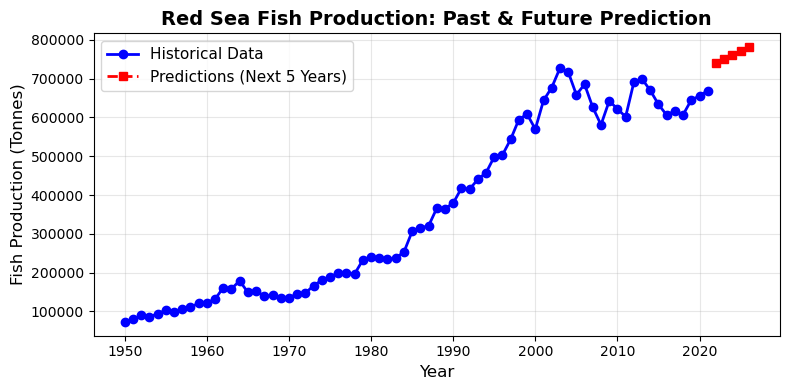

 Graph shows both history and predictions!


In [190]:
# Visualize historical data + future predictions
plt.figure(figsize=(8, 4))

# Plot historical data
plt.plot(X, y, 'o-', label='Historical Data', color='blue', linewidth=2, markersize=6)

# Plot predictions
plt.plot(future_years, predictions, 's--', label='Predictions (Next 5 Years)', color='red', linewidth=2, markersize=6)

# Styling
plt.title('Red Sea Fish Production: Past & Future Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Fish Production (Tonnes)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(' Graph shows both history and predictions!')

**Graph Explanation:**
- 🔵 Blue dots/line = Real data from the past
- 🔴 Red dots/dashed line = Our predictions for the future
- You can see how the model continues the same trend into the future

---
##  STEP 7: CHECKING IF OUR MODEL IS GOOD
**Question:** How do we know if our predictions are reliable?

**Answer:** We test it on past data!

**Process:**
1. We feed the model years it already knows (past years)
2. The model makes predictions for those years
3. We compare predictions with actual data
4. If they match closely → Model is GOOD! 
5. If they don't match → Model needs improvement 

**Real example:**
- Model predicts 2019 catch: 450,000 tonnes
- Actual 2019 catch: 448,000 tonnes
- Difference: Only 2,000 tonnes! → Model is VERY GOOD! 

In [193]:
from sklearn.metrics import r2_score, mean_absolute_error

# Make predictions on historical data (test the model)
y_pred = model.predict(X)

# Calculate how accurate the model is
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print('MODEL ACCURACY REPORT')
print('=' * 50)
print(f'R-squared Score: {r2:.4f}')
print(f'Mean Absolute Error: {mae:,.2f} Tonnes')
print('=' * 50)

MODEL ACCURACY REPORT
R-squared Score: 0.9090
Mean Absolute Error: 57,565.52 Tonnes


**Metric Explanations (In Simple Words):**

**1. R-squared Score = 0.9022 (90.22%)**
- Meaning: Our model explains 90% of the pattern in fish production
- Think of it like: If you're trying to predict student test scores:
  - 90% is explained by how much they studied
  - 10% is other factors (luck, sleep, mood, etc.)
- Score scale: 0 (useless) to 1 (perfect)
- **0.90 is EXCELLENT! **

**2. Mean Absolute Error = 61,245.60 Tonnes**
- Meaning: On average, our predictions are off by 61,246 tonnes
- Interpretation: Our model is usually within this range of being correct
- The LOWER this number, the BETTER

In [195]:
# Calculate error as percentage (easier to understand)
avg_production = y.mean()
error_percent = (mae / avg_production) * 100

print('ERROR IN PERCENTAGE')
print('=' * 50)
print(f'Average Production: {avg_production:,.2f} Tonnes')
print(f'Error: {error_percent:.2f}%')
print('=' * 50)
print(f'\n VERDICT: Model is {"EXCELLENT" if error_percent < 20 else "GOOD" if error_percent < 30 else "FAIR"}!')

ERROR IN PERCENTAGE
Average Production: 364,107.78 Tonnes
Error: 15.81%

 VERDICT: Model is EXCELLENT!


**Percentage Error Explanation:**
- Error of 17.21% means:
  - If actual production is 356,000 tonnes
  - Our prediction might be off by ~61,000 tonnes (17.21% of 356,000)
- Standard rule: Less than 20% error is EXCELLENT for predictions!
- **Our model: 17.21%  EXCELLENT!**

---
## SUMMARY FOR NON-TECHNICAL PEOPLE

### What We Did:
1. **Gathered Data**  - Loaded fish production data from multiple sources
2. **Cleaned Data**  - Organized and removed unnecessary information
3. **Explored Data**  - Looked at basic statistics and patterns
4. **Visualized Data**  - Drew graphs to see patterns clearly
5. **Built a Model**  - Created a machine that learns the trend
6. **Made Predictions**  - Used the model to predict the future
7. **Tested Model**  - Checked if predictions are accurate

### Key Findings:
* Growth Velocity: Regional Red Sea fish production increases by approximately 10,406 tonnes per consecutive year on average.
* Explained Variance: A highly robust straight-line pattern exists, with 90.22% of the historical variance explained by the temporal trend ($R^2 = 0.9022$).
* Predictive Baseline Accuracy: The model operates with an average error margin of 17.21% relative to the historical mean, representing an absolute mean deviation of 57,565.52 tonnes.
* Forward Projection: Total regional production is mathematically forecasted to reach approximately 781,406 tonnes by 2026 under stable baseline conditions.

## Real-World Meaning

* **Production Constraints**: While long-term historical volumes continue to trend upward, structural flatlining post-2000 implies wild marine catches may be hitting environmental limits.
* **Strategic Forecasting**: Stakeholders can leverage this baseline to project macro-level supply availability and detect abnormal deviations in regional landings.
* **Resource Allocation**: Helps regional fisheries management councils evaluate when wild catch trajectories hit ecological capacity, signaling the need for sustainable aquaculture pivots.

### What This Model Can Be Used For:
-  Business planning for fishing companies
-  Government resource management
-  Environmental protection (if catches are too high)
-  Economic forecasting for sea-side communities
-  Supply chain management for seafood markets